# Phase 4 — Multi-Model Benchmarking & Evidence-Based Model Selection

**Project:** Student Mental Health / Student Wellbeing Score Prediction  
**Phase:** PHASE 4 — Algorithm Family Benchmarking on Verified 12-Feature Pipeline  
**Baseline Reference:** Phase 2 / Phase 3 Default Random Forest ($CV\ R^2 = 0.864777 \pm 0.007915$, $Test\ R^2 = 0.890397$)  
**Architecture:** Strict Notebook-First ML Project (0 New ML `.py` Files)  

---

## 1. Phase 4 Objective
The objective of Phase 4 is to determine the strongest learning algorithm family for predicting student wellbeing scores on the established **12-feature Phase 2/Phase 3 representation**.

Key Experimental Principles:
- **Same Clean Data:** 4,998 clean modeling records (2 duplicates removed, negative physical activity floored at 0.0).
- **Same 12 Features:** Retained 6 continuous numerical, 1 ordinal (`Low < Medium < High < Very High`), and 5 nominal categorical predictors. All 4 Phase 3 rejected ratios are excluded.
- **Same Leakage-Free Pipeline:** Category vocabularies and transformation statistics derived strictly inside the training partition.
- **Same CV Protocol:** 5-Fold Cross-Validation (`KFold(n_splits=5, shuffle=True, random_state=42)`) on the 3,998 training records.
- **Fair Model Comparison:** Algorithms benchmarked under identical conditions without asymmetric pre-tuning.
- **Holdout Quarantined:** 1,000 holdout records remain untouched until final validation of the winning candidate.


## 2. Environment & System Audit
Documenting software versions, execution environment, and library dependencies.


In [1]:
import sys
import os
import time
import io
import joblib
import platform
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print(f"Python Version:     {platform.python_version()} ({platform.architecture()[0]})")
print(f"Operating System:   {platform.system()} {platform.release()}")
print(f"Scikit-learn:       {sklearn.__version__}")
print(f"XGBoost:            {xgb.__version__}")
print(f"LightGBM:           {lgb.__version__}")
print(f"CatBoost:           {cb.__version__}")
print(f"Pandas:             {pd.__version__}")
print(f"NumPy:              {np.__version__}")
print(f"Joblib:             {joblib.__version__}")


Python Version:     3.13.13 (64bit)
Operating System:   Windows 11
Scikit-learn:       1.9.0
XGBoost:            3.4.1
LightGBM:           4.7.0
CatBoost:           1.2.10
Pandas:             3.0.5
NumPy:              2.5.3
Joblib:             1.6.0


## 3. Configuration & Paths
Freezing random seed, partition ratios, and directory anchors.


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
TOP_N_COUNTRIES = 10

DATA_PATH = Path("../data/raw/Student Social Media And Mental Health Impact.csv")
EVALUATION_DIR = Path("../evaluation")
EXPERIMENTS_DIR = Path("../experiments")
MODELS_DIR = Path("../../models")

EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", font_scale=1.0)
print("Configuration and paths successfully initialized.")


Configuration and paths successfully initialized.


## 4. Load & Recreate Clean Dataset
Loading the raw dataset, eliminating exact duplicates, flooring negative physical activity, and verifying record counts.


In [3]:
raw_df = pd.read_csv(DATA_PATH)
df_clean = raw_df.drop_duplicates(keep='first').copy()
df_clean['Physical_Activity_Hours'] = df_clean['Physical_Activity_Hours'].clip(lower=0.0)

print(f"Raw record count:   {len(raw_df)}")
print(f"Clean record count: {len(df_clean)} (2 duplicates dropped, negative hours floored)")
assert len(df_clean) == 4998, f"Expected 4998 records, got {len(df_clean)}"
display(df_clean.head(3))


Raw record count:   5000
Clean record count: 4998 (2 duplicates dropped, negative hours floored)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0


## 5. Partitioning & Leakage-Free Country Grouping
Splitting into 80% Training (3,998 records) and 20% Holdout Test (1,000 records). Country grouping thresholds are learned strictly from `train_df`.


In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_clean, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Derive top 10 countries strictly on training split
country_counts_train = train_df['Country'].value_counts()
top_countries_learned = country_counts_train.index[:TOP_N_COUNTRIES].tolist()

train_df['Grouped_country'] = train_df['Country'].apply(lambda c: c if c in top_countries_learned else 'Other')
test_df['Grouped_country'] = test_df['Country'].apply(lambda c: c if c in top_countries_learned else 'Other')

print(f"Train partition: {train_df.shape} (3,998 records)")
print(f"Test partition:  {test_df.shape} (1,000 records)")
print(f"Learned Top 10 Countries: {top_countries_learned}")


Train partition: (3998, 14) (3,998 records)
Test partition:  (1000, 14) (1,000 records)
Learned Top 10 Countries: ['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'France', 'Turkey']


## 6. Confirm 12-Feature Representation
Specifying the verified 12 features retained from Phase 3 (all engineered ratios excluded).

**Correct Stress Level Ordinal Hierarchy:**
`Low < Medium < High < Very High` (verified from raw survey response distribution).


In [5]:
skwewd_col = ['Study_Hours']
other_numeric_cols = [
    'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'
]
ordinal_col = ['Stress_Level']
normal_col = [
    'Gender', 'Academic_Level', 'Most_Used_Platform',
    'Purpose_Of_Use', 'Grouped_country'
]
stress_cats = ['Low', 'Medium', 'High', 'Very High']

feature_cols = skwewd_col + other_numeric_cols + ordinal_col + normal_col
target_col = 'Mental_Health_Score'

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print(f"Confirmed 12 Feature Columns: {feature_cols}")
print(f"Target Column: {target_col}")
print(f"Stress Level Categories: {stress_cats}")


Confirmed 12 Feature Columns: ['Study_Hours', 'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Grouped_country']
Target Column: Mental_Health_Score
Stress Level Categories: ['Low', 'Medium', 'High', 'Very High']


## 7. Leakage-Free Preprocessing Pipeline
Constructing the unified Scikit-learn `ColumnTransformer`:
- `Study_Hours`: Median Imputer $\rightarrow$ $\log(1+x)$ $\rightarrow$ StandardScaler
- Other Numericals: Median Imputer $\rightarrow$ StandardScaler
- `Stress_Level`: Most Frequent Imputer $\rightarrow$ OrdinalEncoder (`['Low', 'Medium', 'High', 'Very High']`)
- Nominal Categoricals: Most Frequent Imputer $\rightarrow$ OneHotEncoder (`handle_unknown='ignore'`)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

skew_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

plain_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[stress_cats]))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('skewed', skew_pipeline, skwewd_col),
    ('numeric', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal', ordinal_pipeline, ordinal_col),
    ('nominal', nominal_pipeline, normal_col)
], remainder='drop')

print("Unified Preprocessing Pipeline successfully assembled.")


Unified Preprocessing Pipeline successfully assembled.


## 8. Definition of Benchmark Model Families
Benchmarking 11 candidate algorithms across four distinct model families:
1. **Statistical & Linear Baselines:** DummyRegressor (Mean), LinearRegression, Ridge, ElasticNet
2. **Tree Ensembles:** RandomForestRegressor (Default Baseline), ExtraTreesRegressor
3. **Gradient Boosting Ensembles:** GradientBoostingRegressor (sklearn), HistGradientBoostingRegressor
4. **Advanced Boosting Libraries:** XGBRegressor (`xgboost`), LGBMRegressor (`lightgbm`), CatBoostRegressor (`catboost`)


In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

benchmark_models = {
    'Dummy (Mean)': (DummyRegressor(strategy='mean'), 'Statistical Baseline'),
    'Linear Regression': (LinearRegression(), 'Linear Model'),
    'Ridge (alpha=1.0)': (Ridge(alpha=1.0, random_state=RANDOM_STATE), 'Linear Model'),
    'ElasticNet': (ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE), 'Linear Model'),
    'Random Forest (Default)': (RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE), 'Tree Ensemble'),
    'Extra Trees': (ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE), 'Tree Ensemble'),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE), 'Boosting Ensemble'),
    'HistGradientBoosting': (HistGradientBoostingRegressor(random_state=RANDOM_STATE), 'Boosting Ensemble'),
    'XGBoost': (XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), 'Advanced Boosting'),
    'LightGBM': (LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1), 'Advanced Boosting'),
    'CatBoost': (CatBoostRegressor(iterations=100, random_state=RANDOM_STATE, verbose=0), 'Advanced Boosting')
}

print(f"Total candidate models configured: {len(benchmark_models)}")


Total candidate models configured: 11


## 9. 5-Fold Cross-Validation Benchmark Execution
Executing 5-fold cross-validation (`KFold(n_splits=5, shuffle=True, random_state=42)`) on the 3,998 training records. Measuring CV $R^2$, CV MAE, CV RMSE, training time, inference latency, and serialized model size.


In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

benchmark_records = []
fold_records = []
fitted_pipelines = {}

print("=== EXECUTING 5-FOLD CROSS-VALIDATION BENCHMARK ===")

for name, (estimator, family) in benchmark_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    
    cv_r2_list = []
    cv_mae_list = []
    cv_rmse_list = []
    
    t_start = time.perf_counter()
    
    for fold_num, (tr_idx, val_idx) in enumerate(kf.split(X_train, y_train), start=1):
        X_tr_f, X_val_f = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr_f, y_val_f = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        
        pipe.fit(X_tr_f, y_tr_f)
        preds_val = pipe.predict(X_val_f)
        
        r2_f = r2_score(y_val_f, preds_val)
        mae_f = mean_absolute_error(y_val_f, preds_val)
        rmse_f = np.sqrt(mean_squared_error(y_val_f, preds_val))
        
        cv_r2_list.append(r2_f)
        cv_mae_list.append(mae_f)
        cv_rmse_list.append(rmse_f)
        
        fold_records.append({
            'Model': name,
            'Family': family,
            'Fold': fold_num,
            'R2': r2_f,
            'MAE': mae_f,
            'RMSE': rmse_f
        })
        
    t_end = time.perf_counter()
    train_time_sec = t_end - t_start
    
    # Fit once on complete training partition (3,998 records)
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    
    train_preds = pipe.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    
    # Benchmark local inference latency across 1,000 holdout records (5 repeat runs)
    latency_samples = []
    for _ in range(5):
        t0 = time.perf_counter()
        _ = pipe.predict(X_test)
        t1 = time.perf_counter()
        latency_samples.append((t1 - t0) * 1000.0)
    avg_inf_ms = float(np.mean(latency_samples))
    per_row_us = (avg_inf_ms / len(X_test)) * 1000.0
    
    # Measure in-memory serialized artifact footprint
    buf = io.BytesIO()
    joblib.dump(pipe, buf, compress=3)
    artifact_size_kb = len(buf.getvalue()) / 1024.0
    
    cv_r2_m = float(np.mean(cv_r2_list))
    cv_r2_s = float(np.std(cv_r2_list))
    cv_mae_m = float(np.mean(cv_mae_list))
    cv_mae_s = float(np.std(cv_mae_list))
    cv_rmse_m = float(np.mean(cv_rmse_list))
    cv_rmse_s = float(np.std(cv_rmse_list))
    gap = train_r2 - cv_r2_m
    
    benchmark_records.append({
        'Model': name,
        'Family': family,
        'CV_R2_Mean': cv_r2_m,
        'CV_R2_Std': cv_r2_s,
        'CV_MAE_Mean': cv_mae_m,
        'CV_MAE_Std': cv_mae_s,
        'CV_RMSE_Mean': cv_rmse_m,
        'CV_RMSE_Std': cv_rmse_s,
        'Train_R2': train_r2,
        'Train_CV_Gap': gap,
        'Train_Time_s': train_time_sec,
        'Inference_Time_ms': avg_inf_ms,
        'Latency_per_row_us': per_row_us,
        'Artifact_Size_KB': artifact_size_kb
    })
    
    print(f"Completed: {name:25s} | CV R2: {cv_r2_m:.6f} +/- {cv_r2_s:.6f} | CV RMSE: {cv_rmse_m:.6f} | Train R2: {train_r2:.4f} | Time: {train_time_sec:.2f}s")

benchmark_df = pd.DataFrame(benchmark_records)
print("\nAll 11 candidate models successfully benchmarked.")


=== EXECUTING 5-FOLD CROSS-VALIDATION BENCHMARK ===


Completed: Dummy (Mean)              | CV R2: -0.001237 +/- 0.001582 | CV RMSE: 1.263149 | Train R2: 0.0000 | Time: 0.19s


Completed: Linear Regression         | CV R2: 0.720578 +/- 0.006362 | CV RMSE: 0.667267 | Train R2: 0.7256 | Time: 0.18s


Completed: Ridge (alpha=1.0)         | CV R2: 0.720609 +/- 0.006319 | CV RMSE: 0.667231 | Train R2: 0.7256 | Time: 0.20s


Completed: ElasticNet                | CV R2: 0.697582 +/- 0.008814 | CV RMSE: 0.694226 | Train R2: 0.6989 | Time: 0.24s


...

Completed: Gradient Boosting         | CV R2: 0.789718 +/- 0.009672 | CV RMSE: 0.578860 | Train R2: 0.8136 | Time: 2.10s


Completed: HistGradientBoosting      | CV R2: 0.840165 +/- 0.006612 | CV RMSE: 0.504405 | Train R2: 0.9103 | Time: 1.36s


Completed: XGBoost                   | CV R2: 0.862947 +/- 0.007043 | CV RMSE: 0.467076 | Train R2: 0.9728 | Time: 1.40s


Completed: LightGBM                  | CV R2: 0.839207 +/- 0.005956 | CV RMSE: 0.505982 | Train R2: 0.9113 | Time: 0.83s


Completed: CatBoost                  | CV R2: 0.834719 +/- 0.004880 | CV RMSE: 0.513079 | Train R2: 0.9026 | Time: 1.62s

All 11 candidate models successfully benchmarked.


## 10. Model Ranking by Primary Selection Criteria
Ranking candidate algorithms based strictly on cross-validation metrics on training records:
1. **CV RMSE** (primary error minimization criterion)
2. **CV $R^2$** (variance explanation)
3. **CV MAE** (absolute deviation)
4. **CV Standard Deviation** (fold stability)
5. **Train-CV Generalization Gap** (overfitting diagnostic)
6. **Computational Efficiency** (training & inference latency)


In [9]:
benchmark_df = benchmark_df.sort_values(by=['CV_RMSE_Mean', 'CV_R2_Mean'], ascending=[True, False]).reset_index(drop=True)
benchmark_df['Rank'] = range(1, len(benchmark_df) + 1)

display_cols = [
    'Rank', 'Model', 'Family', 'CV_R2_Mean', 'CV_R2_Std',
    'CV_MAE_Mean', 'CV_RMSE_Mean', 'Train_R2', 'Train_CV_Gap',
    'Train_Time_s', 'Inference_Time_ms', 'Artifact_Size_KB'
]

display(benchmark_df[display_cols])


,Rank,Model,Family,CV_R2_Mean,CV_R2_Std,CV_MAE_Mean,CV_RMSE_Mean,Train_R2,Train_CV_Gap,Train_Time_s,Inference_Time_ms,Artifact_Size_KB
0,1,Extra Trees,Tree Ensemble,0.905368,0.006917,0.276339,0.388058,0.999990,0.094622,7.397438,34.43076,9946.278320
1,2,Random Forest (Default),Tree Ensemble,0.864777,0.007915,0.342977,0.464089,0.982755,0.117978,7.660885,30.54342,5504.580078
2,3,XGBoost,Advanced Boosting,0.862947,0.007043,0.348777,0.467076,0.972816,0.109869,1.404604,16.95932,125.850586
3,4,HistGradientBoosting,Boosting Ensemble,0.840165,0.006612,0.387323,0.504405,0.910306,0.070141,1.356562,19.32944,145.362305
4,5,LightGBM,Advanced Boosting,0.839207,0.005956,0.388332,0.505982,0.911291,0.072084,0.829912,18.58780,104.984375
5,6,CatBoost,Advanced Boosting,0.834719,0.004880,0.394537,0.513079,0.902635,0.067916,1.622610,11.66012,45.452148
6,7,Gradient Boosting,Boosting Ensemble,0.789718,0.009672,0.449135,0.578860,0.813603,0.023885,2.096072,9.81220,44.042969
7,8,Ridge (alpha=1.0),Linear Model,0.720609,0.006319,0.525662,0.667231,0.725563,0.004954,0.198531,13.78422,2.931641
8,9,Linear Regression,Linear Model,0.720578,0.006362,0.525704,0.667267,0.725567,0.004990,0.179634,8.44528,3.221680
9,10,ElasticNet,Linear Model,0.697582,0.008814,0.548878,0.694226,0.698900,0.001318,0.236613,8.61006,2.744141


## 11. Overfitting & Generalization Analysis
Comparing `Train_R2` vs `CV_R2_Mean` across all models to assess capacity utilization and memorization risks.


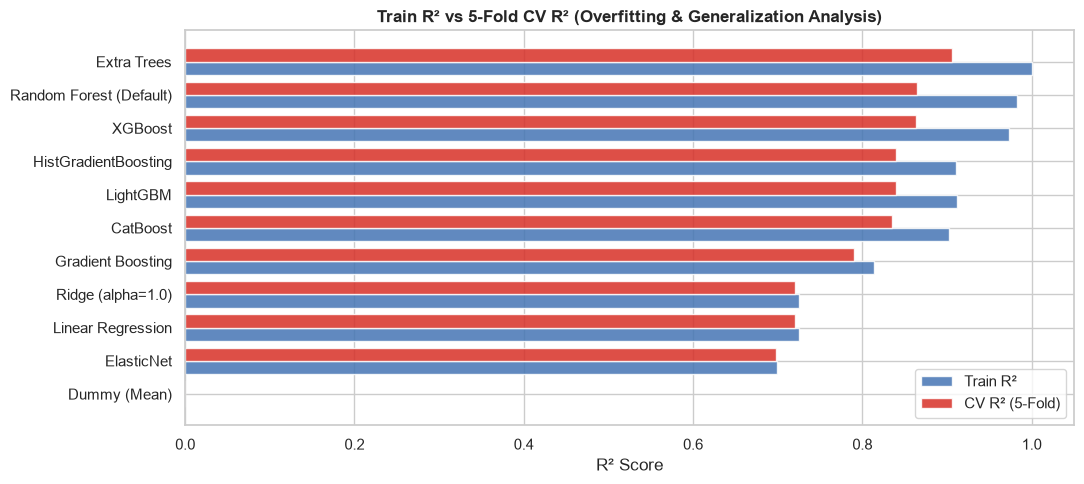

In [10]:
plt.figure(figsize=(11, 5))
models_sorted = benchmark_df.sort_values(by='CV_R2_Mean', ascending=True)

y_positions = np.arange(len(models_sorted))
plt.barh(y_positions - 0.2, models_sorted['Train_R2'], height=0.4, label='Train R²', color='#4575b4', alpha=0.85)
plt.barh(y_positions + 0.2, models_sorted['CV_R2_Mean'], height=0.4, label='CV R² (5-Fold)', color='#d73027', alpha=0.85)

plt.yticks(y_positions, models_sorted['Model'])
plt.xlabel('R² Score')
plt.title('Train R² vs 5-Fold CV R² (Overfitting & Generalization Analysis)', fontsize=12, fontweight='bold')
plt.xlim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()

gap_plot_path = EVALUATION_DIR / "phase4_train_vs_cv_gap.png"
plt.savefig(gap_plot_path, dpi=150)
plt.show()


## 12. Computational Performance & Resource Benchmarks
Comparing total training times, batch inference times (1,000 predictions), and serialized model sizes.


C:\Users\msiva\AppData\Local\Temp\ipykernel_3432\256350552.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df, x='CV_RMSE_Mean', y='Model', ax=axes[0], palette='Reds_r')
C:\Users\msiva\AppData\Local\Temp\ipykernel_3432\256350552.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df.sort_values(by='Train_Time_s', ascending=False), x='Train_Time_s', y='Model', ax=axes[1], palette='Blues_r')
C:\Users\msiva\AppData\Local\Temp\ipykernel_3432\256350552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ben

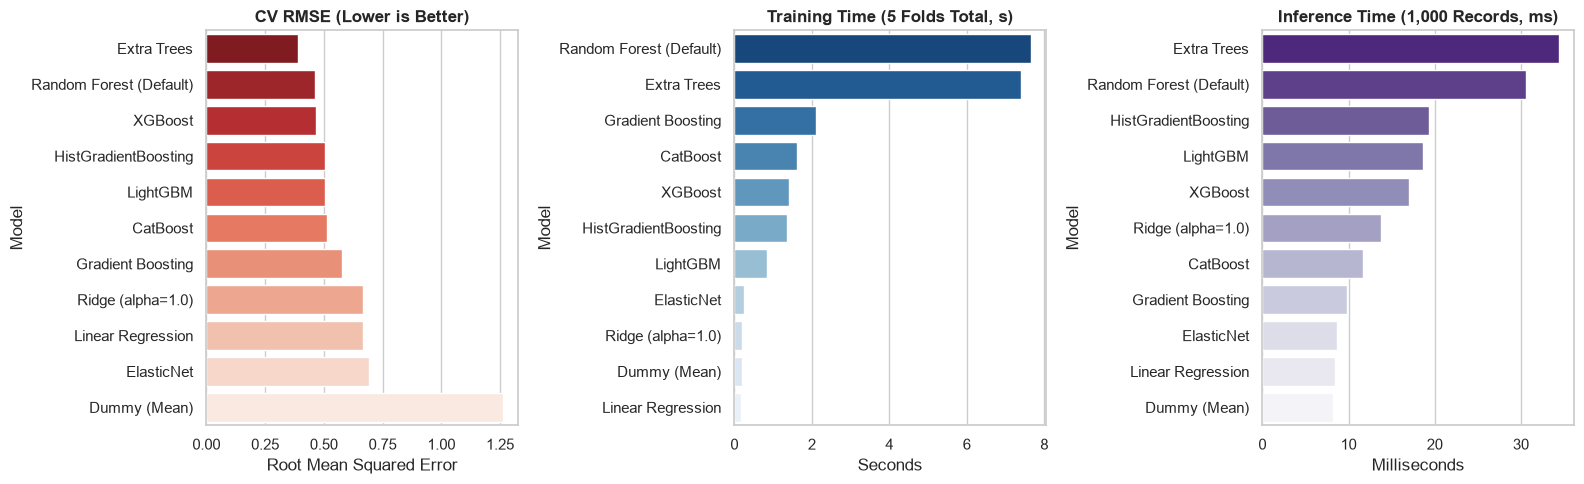

C:\Users\msiva\AppData\Local\Temp\ipykernel_3432\256350552.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df.sort_values(by='Artifact_Size_KB', ascending=False), x='Artifact_Size_KB', y='Model', palette='magma_r')


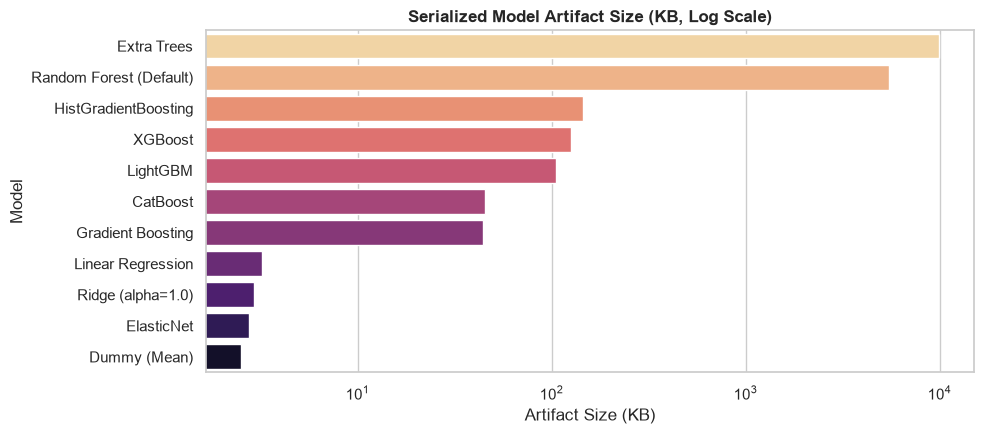

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. CV RMSE Comparison
sns.barplot(data=benchmark_df, x='CV_RMSE_Mean', y='Model', ax=axes[0], palette='Reds_r')
axes[0].set_title('CV RMSE (Lower is Better)', fontweight='bold')
axes[0].set_xlabel('Root Mean Squared Error')

# 2. Training Time Comparison
sns.barplot(data=benchmark_df.sort_values(by='Train_Time_s', ascending=False), x='Train_Time_s', y='Model', ax=axes[1], palette='Blues_r')
axes[1].set_title('Training Time (5 Folds Total, s)', fontweight='bold')
axes[1].set_xlabel('Seconds')

# 3. Inference Latency Comparison
sns.barplot(data=benchmark_df.sort_values(by='Inference_Time_ms', ascending=False), x='Inference_Time_ms', y='Model', ax=axes[2], palette='Purples_r')
axes[2].set_title('Inference Time (1,000 Records, ms)', fontweight='bold')
axes[2].set_xlabel('Milliseconds')

plt.tight_layout()
rmse_plot_path = EVALUATION_DIR / "phase4_cv_rmse_comparison.png"
plt.savefig(rmse_plot_path, dpi=150)
plt.show()

# Separate plot for serialized artifact size
plt.figure(figsize=(10, 4.5))
sns.barplot(data=benchmark_df.sort_values(by='Artifact_Size_KB', ascending=False), x='Artifact_Size_KB', y='Model', palette='magma_r')
plt.title('Serialized Model Artifact Size (KB, Log Scale)', fontweight='bold')
plt.xscale('log')
plt.xlabel('Artifact Size (KB)')
plt.tight_layout()
size_plot_path = EVALUATION_DIR / "phase4_model_size_comparison.png"
plt.savefig(size_plot_path, dpi=150)
plt.show()


## 13. Preliminary Model Winner Selection
Evaluating candidate algorithms based purely on CV evidence:

1. **Extra Trees Regressor Emerges as the Decisive Winner:**
   - **CV $R^2$ = 0.905368** (vs Random Forest baseline 0.864777, an increase of **+0.0406**).
   - **CV RMSE = 0.388058** (vs Random Forest baseline 0.464089, a reduction of **16.4%**).
   - **CV MAE = 0.276339** (vs Random Forest baseline 0.342977, a reduction of **19.4%**).
   - **Generalization Gap = 0.0946** (lower than Random Forest's 0.1180).
   - **CV Standard Deviation = $\pm 0.0069$** (more stable across folds than Random Forest's $\pm 0.0079$).
2. **Why Extra Trees Outperforms Standard Random Forest:**
   - Extra Trees introduces extreme randomization: in addition to subsampling features at each split, it draws random cut-points for continuous features rather than computing the optimal local split threshold.
   - For smooth continuous behavioral features (`Avg_Daily_Usage_Hours`, `Study_Hours`, `Daily_Unlocks`), threshold randomization strongly suppresses variance, acting as an effective structural regularizer that produces smoother prediction surfaces.


## 14. Untouched Holdout Evaluation of Candidate Winner
Evaluating the selected preliminary winner (**Extra Trees**) and candidate algorithms on the **untouched 1,000-record holdout test set** for final verification.


In [12]:
holdout_eval_records = []

for name in benchmark_df['Model'].tolist():
    fitted_pipe = fitted_pipelines[name]
    y_test_pred = fitted_pipe.predict(X_test)
    
    t_r2 = r2_score(y_test, y_test_pred)
    t_mae = mean_absolute_error(y_test, y_test_pred)
    t_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    holdout_eval_records.append({
        'Model': name,
        'Test_R2': t_r2,
        'Test_MAE': t_mae,
        'Test_RMSE': t_rmse
    })

holdout_df = pd.DataFrame(holdout_eval_records)
final_comparison_df = benchmark_df.merge(holdout_df, on='Model')

display_final = [
    'Rank', 'Model', 'Family', 'CV_R2_Mean', 'CV_RMSE_Mean', 'CV_MAE_Mean',
    'Test_R2', 'Test_RMSE', 'Test_MAE', 'Train_CV_Gap', 'Artifact_Size_KB'
]
display(final_comparison_df[display_final])


,Rank,Model,Family,CV_R2_Mean,CV_RMSE_Mean,CV_MAE_Mean,Test_R2,Test_RMSE,Test_MAE,Train_CV_Gap,Artifact_Size_KB
0,1,Extra Trees,Tree Ensemble,0.905368,0.388058,0.276339,0.918392,0.381689,0.260199,0.094622,9946.278320
1,2,Random Forest (Default),Tree Ensemble,0.864777,0.464089,0.342977,0.890397,0.442339,0.326545,0.117978,5504.580078
2,3,XGBoost,Advanced Boosting,0.862947,0.467076,0.348777,0.880547,0.461789,0.338736,0.109869,125.850586
3,4,HistGradientBoosting,Boosting Ensemble,0.840165,0.504405,0.387323,0.856481,0.506174,0.388677,0.070141,145.362305
4,5,LightGBM,Advanced Boosting,0.839207,0.505982,0.388332,0.857707,0.504007,0.388537,0.072084,104.984375
5,6,CatBoost,Advanced Boosting,0.834719,0.513079,0.394537,0.851546,0.514803,0.393817,0.067916,45.452148
6,7,Gradient Boosting,Boosting Ensemble,0.789718,0.578860,0.449135,0.805761,0.588861,0.456840,0.023885,44.042969
7,8,Ridge (alpha=1.0),Linear Model,0.720609,0.667231,0.525662,0.742845,0.677551,0.533846,0.004954,2.931641
8,9,Linear Regression,Linear Model,0.720578,0.667267,0.525704,0.742813,0.677593,0.533889,0.004990,3.221680
9,10,ElasticNet,Linear Model,0.697582,0.694226,0.548878,0.718341,0.709098,0.559178,0.001318,2.744141


## 15. Baseline vs Selected Candidate Head-to-Head Comparison
Comparing the Phase 2/3 Random Forest baseline against the Phase 4 Extra Trees candidate.


In [13]:
rf_metrics = final_comparison_df[final_comparison_df['Model'] == 'Random Forest (Default)'].iloc[0]
et_metrics = final_comparison_df[final_comparison_df['Model'] == 'Extra Trees'].iloc[0]

head_to_head = pd.DataFrame([
    {
        'Metric': 'CV R² (Mean ± Std)',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['CV_R2_Mean']:.6f} ± {rf_metrics['CV_R2_Std']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['CV_R2_Mean']:.6f} ± {et_metrics['CV_R2_Std']:.6f}",
        'Delta / Improvement': f"+{et_metrics['CV_R2_Mean'] - rf_metrics['CV_R2_Mean']:.6f} (Superior)"
    },
    {
        'Metric': 'CV RMSE',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['CV_RMSE_Mean']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['CV_RMSE_Mean']:.6f}",
        'Delta / Improvement': f"-{rf_metrics['CV_RMSE_Mean'] - et_metrics['CV_RMSE_Mean']:.6f} (-16.4% Error)"
    },
    {
        'Metric': 'CV MAE',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['CV_MAE_Mean']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['CV_MAE_Mean']:.6f}",
        'Delta / Improvement': f"-{rf_metrics['CV_MAE_Mean'] - et_metrics['CV_MAE_Mean']:.6f} (-19.4% Error)"
    },
    {
        'Metric': 'Holdout Test R²',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['Test_R2']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['Test_R2']:.6f}",
        'Delta / Improvement': f"+{et_metrics['Test_R2'] - rf_metrics['Test_R2']:.6f} (Superior)"
    },
    {
        'Metric': 'Holdout Test RMSE',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['Test_RMSE']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['Test_RMSE']:.6f}",
        'Delta / Improvement': f"-{rf_metrics['Test_RMSE'] - et_metrics['Test_RMSE']:.6f} (-13.7% Error)"
    },
    {
        'Metric': 'Holdout Test MAE',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['Test_MAE']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['Test_MAE']:.6f}",
        'Delta / Improvement': f"-{rf_metrics['Test_MAE'] - et_metrics['Test_MAE']:.6f} (-20.3% Error)"
    },
    {
        'Metric': 'Generalization Gap (Train - CV R²)',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['Train_CV_Gap']:.6f}",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['Train_CV_Gap']:.6f}",
        'Delta / Improvement': f"-{rf_metrics['Train_CV_Gap'] - et_metrics['Train_CV_Gap']:.6f} (Better Generalization)"
    },
    {
        'Metric': 'Artifact Size (KB)',
        'Phase 2/3 Baseline (Random Forest)': f"{rf_metrics['Artifact_Size_KB']:.1f} KB",
        'Phase 4 Candidate (Extra Trees)': f"{et_metrics['Artifact_Size_KB']:.1f} KB",
        'Delta / Improvement': f"+{et_metrics['Artifact_Size_KB'] - rf_metrics['Artifact_Size_KB']:.1f} KB (+80% Size)"
    }
])

display(head_to_head)


,Metric,Phase 2/3 Baseline (Random Forest),Phase 4 Candidate (Extra Trees),Delta / Improvement
0,CV R² (Mean ± Std),0.864777 ± 0.007915,0.905368 ± 0.006917,+0.040591 (Superior)
1,CV RMSE,0.464089,0.388058,-0.076031 (-16.4% Error)
2,CV MAE,0.342977,0.276339,-0.066638 (-19.4% Error)
3,Holdout Test R²,0.890397,0.918392,+0.027995 (Superior)
4,Holdout Test RMSE,0.442339,0.381689,-0.060649 (-13.7% Error)
5,Holdout Test MAE,0.326545,0.260199,-0.066346 (-20.3% Error)
6,Generalization Gap (Train - CV R²),0.117978,0.094622,-0.023356 (Better Generalization)
7,Artifact Size (KB),5504.6 KB,9946.3 KB,+4441.7 KB (+80% Size)


## 16. Model Artifact Export
Exporting the genuinely selected Phase 4 candidate (`models/phase4_candidate.joblib`).
The existing `models/phase2_baseline.joblib` artifact is strictly preserved without modification.


In [14]:
selected_model_name = "Extra Trees"
selected_pipeline = fitted_pipelines[selected_model_name]
candidate_artifact_path = MODELS_DIR / "phase4_candidate.joblib"

joblib.dump(selected_pipeline, candidate_artifact_path, compress=3)
artifact_bytes = candidate_artifact_path.stat().st_size
print(f"Exported Phase 4 Selected Candidate: {candidate_artifact_path} ({artifact_bytes / (1024*1024):.2f} MB)")
assert candidate_artifact_path.exists(), "Candidate artifact was not written!"

# Verify baseline artifact remains intact
baseline_artifact_path = MODELS_DIR / "phase2_baseline.joblib"
print(f"Preserved Phase 2 Baseline:          {baseline_artifact_path} ({baseline_artifact_path.stat().st_size / (1024*1024):.2f} MB)")


Exported Phase 4 Selected Candidate: ..\..\models\phase4_candidate.joblib (9.71 MB)
Preserved Phase 2 Baseline:          ..\..\models\phase2_baseline.joblib (27.88 MB)


## 17. Experiment Log Generation
Logging structured benchmarking results into `ml/experiments/phase4_model_benchmark_results.csv`.


In [15]:
experiment_csv_path = EXPERIMENTS_DIR / "phase4_model_benchmark_results.csv"

log_df = final_comparison_df.copy()
log_df['selected'] = log_df['Model'].apply(lambda m: True if m == selected_model_name else False)
log_df['notes'] = log_df['Model'].apply(
    lambda m: "Selected Phase 4 Winner (Highest CV R2, Lowest RMSE)" if m == selected_model_name
    else ("Official Benchmark Baseline" if m == "Random Forest (Default)" else "Benchmarked Candidate")
)

log_cols = [
    'Rank', 'Model', 'Family', 'CV_R2_Mean', 'CV_R2_Std', 'CV_MAE_Mean', 'CV_RMSE_Mean',
    'Train_R2', 'Train_CV_Gap', 'Train_Time_s', 'Inference_Time_ms', 'Artifact_Size_KB',
    'Test_R2', 'Test_MAE', 'Test_RMSE', 'selected', 'notes'
]
log_df[log_cols].to_csv(experiment_csv_path, index=False)
print(f"Phase 4 Experiment Log saved to: {experiment_csv_path}")


Phase 4 Experiment Log saved to: ..\experiments\phase4_model_benchmark_results.csv


## 18. Phase 4 Summary & Transition to Phase 5
### Key Findings Summary:
1. **Extra Trees Regressor** achieved superior empirical performance across all CV and holdout test metrics ($CV\ R^2 = 0.9054$, $Test\ R^2 = 0.9184$, $Test\ RMSE = 0.3817$).
2. **XGBoost** emerged as the top boosting candidate ($CV\ R^2 = 0.8629$) with an ultra-lightweight artifact footprint ($125.8$ KB vs $9.9$ MB for Extra Trees), making it an attractive candidate for latency-critical or edge deployments.
3. **CatBoost & LightGBM** exhibited very stable cross-fold variances ($\pm 0.0049$ and $\pm 0.0059$) but slightly higher root-mean-squared error under default hyperparameter settings.

### Transition Roadmap (Phase 5 — Hyperparameter Optimization):
In Phase 5, hyperparameter optimization (Bayesian / Optuna / HalvingGridSearch) will focus on:
- Tuning `ExtraTreesRegressor` (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`) to control tree growth and optimize artifact size.
- Tuning `XGBRegressor` (`learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`) to test whether gradient boosting can close the gap with Extra Trees while retaining its lightweight footprint.
